# Practica 04: Analisis de Datos Exploratorios con Python y Jupiter Notebook en un Dataset de Productos de Amazon Store

**Programa  de Estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026


### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** Ilse Guadalupe Saavedra Villa \
**Matricula:** 230349 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FFD1DC 0%, #FFFFFF 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">

<h1 style="color: #C71585; font-size: 2.2em; margin: 0;">
🛒 Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #DB7093; font-size: 1.1em; margin-top: 10px;">
Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos
</p>

</div>

---

## Tabla de Contenidos
| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones & Carga de Datos](#s1) | Librerias, carga del CSV, primeros comandos de escritura |
| 2 | [Diccionario de Datos](#s2) | Explicación del contenido de columnas y calcular el % de datos faltantes |
| 3 | [Limpieza de Datos](#3) | Aplicación de métodos básicos de limpieza (eliminación duplicados, agrupación, datos nulos |

## 1. Instalaciones & Carga de Datos <a id='s1'></a>
<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [1]:
# ============================================================
# SECTION 1 - Setup & Data Loading
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

#ML - Machine Learning - Entrenamiento de modelos matematicos para predecir en este caso precios
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'✅ Pandas   : {pd.__version__}')
print(f'✅ NumPy    : {np.__version__}')
print('✅ Todas la librerías cargaron con éxito!')

✅ Pandas   : 2.3.3
✅ NumPy    : 2.3.5
✅ Todas la librerías cargaron con éxito!


In [2]:
# Load dataset

df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f' Shape   : {df_raw.shape}')
print(f' Columns : {df_raw.columns.tolist()}')

df_raw.head(3)

 Shape   : (1445, 17)
 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame.

In [3]:
# Column dictionary
col_info = {
    'rl': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor ',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes ... )',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
}
print('Diccionario por columnas:')
for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() *100
    print(
        f' {col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
)

Diccionario por columnas:
 rl                   | URL del Producto en Amazon.in                 | Missing: 0%
 asin                 | Número Estandarizado de Identificación por Am | Missing: 0%
 name                 | Nombre o Título del Producto                  | Missing: 0%
 overview             | Breve Reseña del Producto (mayoría vacío [])  | Missing: 0%
 price                | Precio como string (e.g. "1,600.00")          | Missing: 24%
 currency             | Código de Divisa (todas en INR)               | Missing: 24%
 availability         | Texto del Status del Stock (Inventario)       | Missing: 33%
 brand                | Nombre de la Marca/Autor                      | Missing: 1%
 about_item           | Detalles/Especificaciones (mayoría faltante)  | Missing: 92%
 img_source           | URLs de Imágenes del Producto                 | Missing: 0%
 description          | Descripción detallada y completa (mayoría fal | Missing: 93%
 specifications       | Especificaciones Técn

## 3. Limpieza de Datos

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [4]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,097 / 1,445 products
✅ Duplicate ASINs: 8
✅ Availability categories: {'In Stock': 607, 'Unknown': 482, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 82, 'Other': 22, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


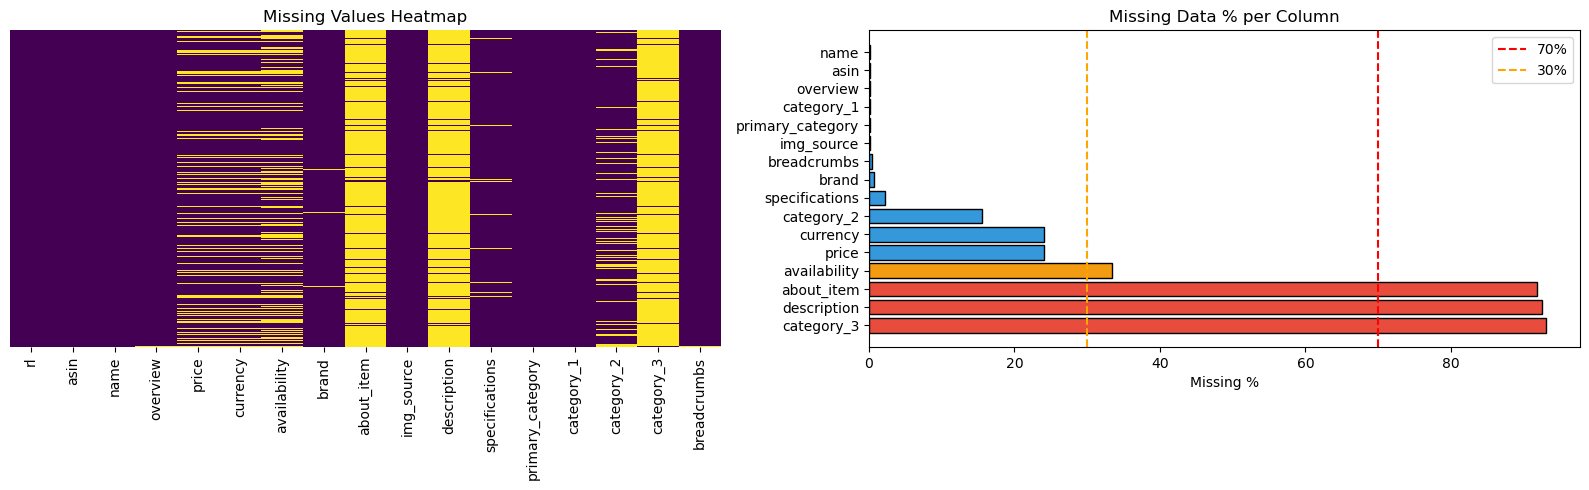

                  Missing Count  Missing Pct
category_3                 1346         93.1
description                1337         92.5
about_item                 1326         91.8
availability                482         33.4
price                       347         24.0
currency                    347         24.0
category_2                  225         15.6
specifications               32          2.2
brand                        10          0.7
breadcrumbs                   6          0.4
img_source                    3          0.2
primary_category              3          0.2
category_1                    3          0.2
overview                      3          0.2
asin                          1          0.1
name                          1          0.1


In [5]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing Pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Aquí corregí 'Viridis' por 'viridis' con minúscula
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]

# Dibujar barras solo si hay columnas con valores faltantes
if not mv.empty:
    axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].set_xlabel('Missing %')
    axes[1].set_title('Missing Data % per Column')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No hay valores faltantes', 
                 horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingeniería de Características (Feature Engineering)




<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;"><b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antigüedad y el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías..</div>

In [6]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int) # Esta instruccion imprime laas columnas df enlistadas en este caso Name,
#isbook que hace referecnia al nombre del producto y un boleano si es libro o no.
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total de características generadas: {len(df.columns)}')
print('\nDistribución de los rangos de precios:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


✅ Total de características generadas: 39

Distribución de los rangos de precios:
price_tier
1_budget     104
2_low        285
3_mid        319
4_premium    261
5_luxury     128
Unknown      348


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis univariado 📊 <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Cómo es la distribución de precios? ¿Hay valores atípicos? ¿Los datos están sesgados?
</div>


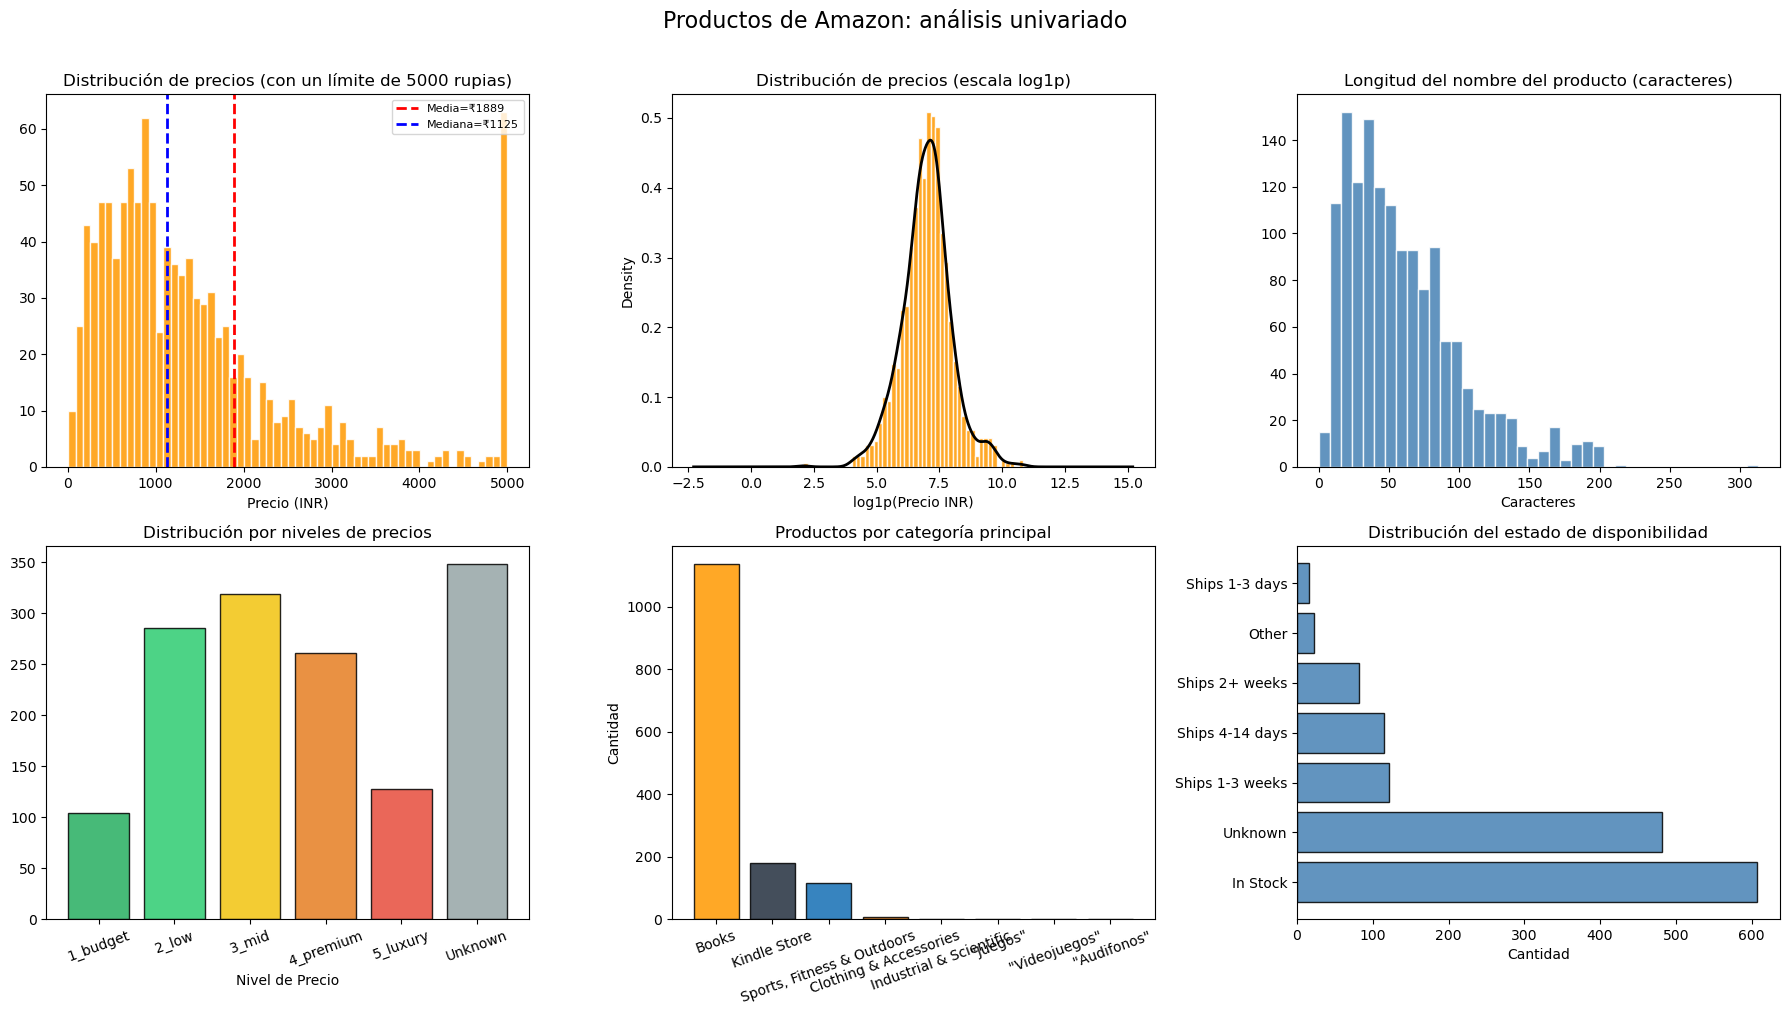

Shapiro-Wilk (precio log, n=500): stat=0.9867, p=0.000158
El precio sigue siendo no normal después de la transformación logarítmica

Estadísticas de precios (INR):
count     1090.00
mean      1888.53
std       3342.12
min          7.00
25%        614.29
50%       1125.00
75%       1853.00
max      50555.00


In [7]:
# ============================================================
# SECCIÓN 4 — Análisis Univariado
# ============================================================
# IMPORTANTE: Añadir esta línea para solucionar el error
import matplotlib.pyplot as plt
from scipy.stats import shapiro

df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Precio original (raw)
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Media=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Mediana=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Distribución de precios (con un límite de 5000 rupias)')
axes[0,0].set_xlabel('Precio (INR)'); axes[0,0].legend(fontsize=8)

# Precio transformado (log)
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Distribución de precios (escala log1p)')
axes[0,1].set_xlabel('log1p(Precio INR)')

# Longitud del nombre
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Longitud del nombre del producto (caracteres)')
axes[0,2].set_xlabel('Caracteres')

# Nivel de precio (Price tier)
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Distribución por niveles de precios')
axes[1,0].set_xlabel('Nivel de Precio'); axes[1,0].tick_params(axis='x', rotation=20)

# Categoría principal
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Productos por categoría principal')
axes[1,1].set_ylabel('Cantidad'); axes[1,1].tick_params(axis='x', rotation=20)

# Disponibilidad
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Distribución del estado de disponibilidad')
axes[1,2].set_xlabel('Cantidad')

plt.suptitle('Productos de Amazon: análisis univariado', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Prueba de normalidad
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (precio log, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'El precio {"distribuye normalmente después de la transformación logarítmica" if p > 0.05 else "sigue siendo no normal después de la transformación logarítmica"}')
print(f'\nEstadísticas de precios (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

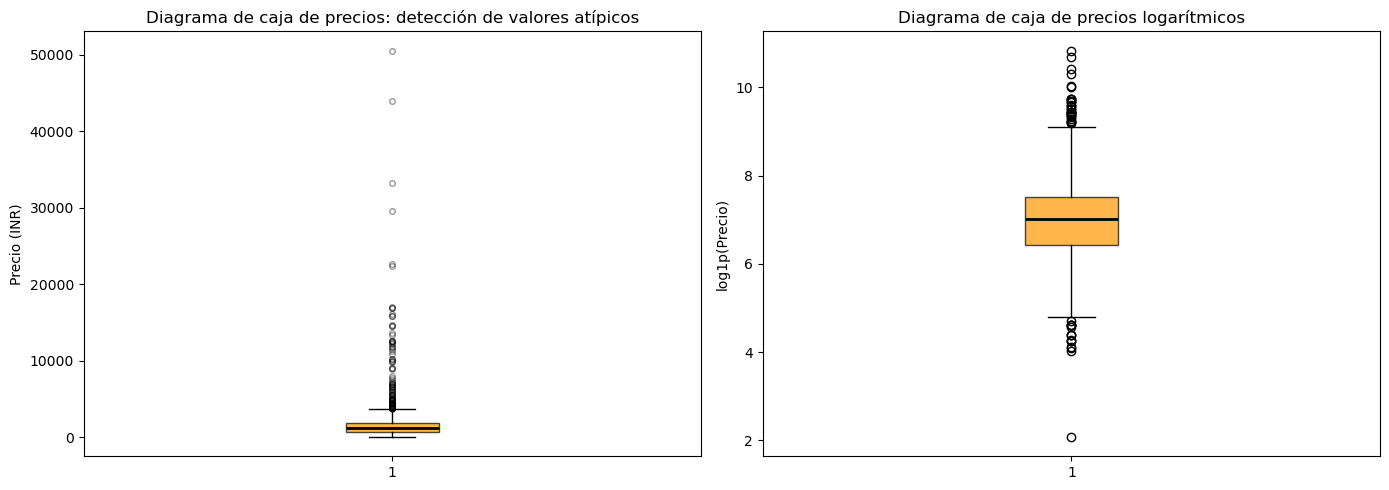

Valores atípicos por método IQR: 94 (8.6%)
Rango de precios (sin valores atípicos): ₹-1244 – ₹3711

Los 10 productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     296

In [8]:
# Análisis de valores atípicos — diagrama de caja (boxplot) e IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Diagrama de caja de precios: detección de valores atípicos')
axes[0].set_ylabel('Precio (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Diagrama de caja de precios logarítmicos')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                     (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'Valores atípicos por método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Rango de precios (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nLos 10 productos más caros:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))


## 6. Análisis de Categorías 🗂️ <a id='s5'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra la mejor relación calidad-precio?

</div>


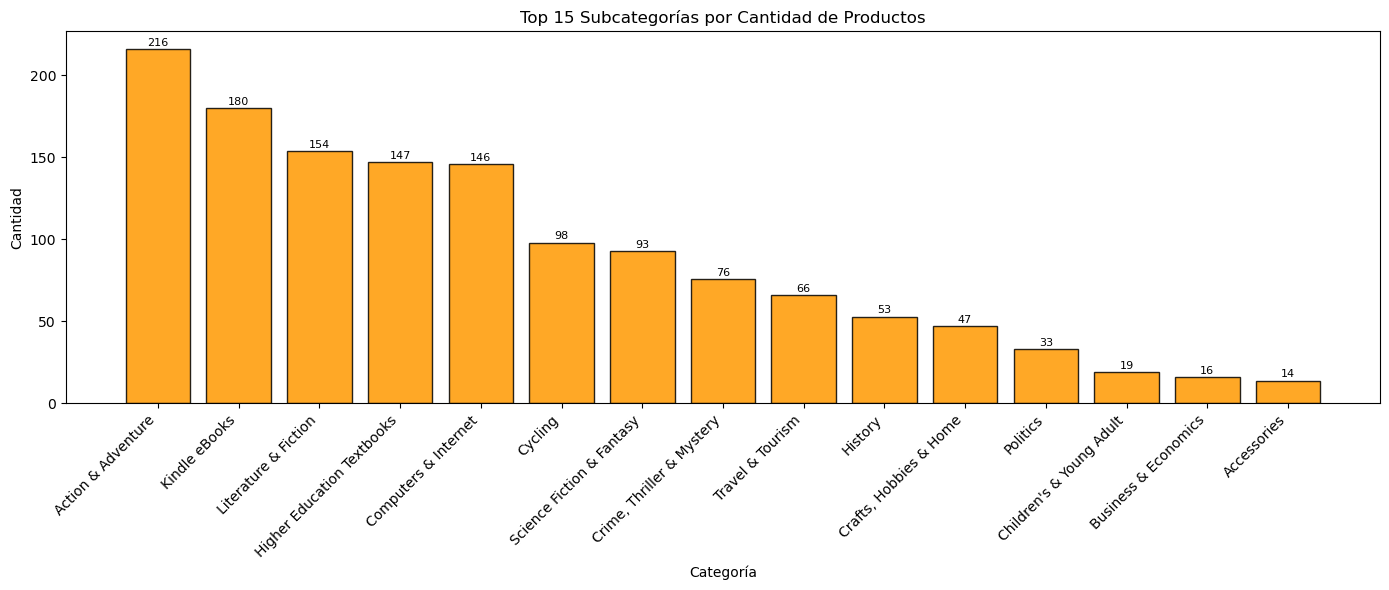

In [9]:
# ============================================================
# SECCIÓN 5 — Análisis de Categorías
# ============================================================
# Las 15 subcategorías principales por cantidad de productos
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)

# Agregar etiquetas de cantidad sobre cada barra
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', fontsize=8)

plt.title('Top 15 Subcategorías por Cantidad de Productos')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

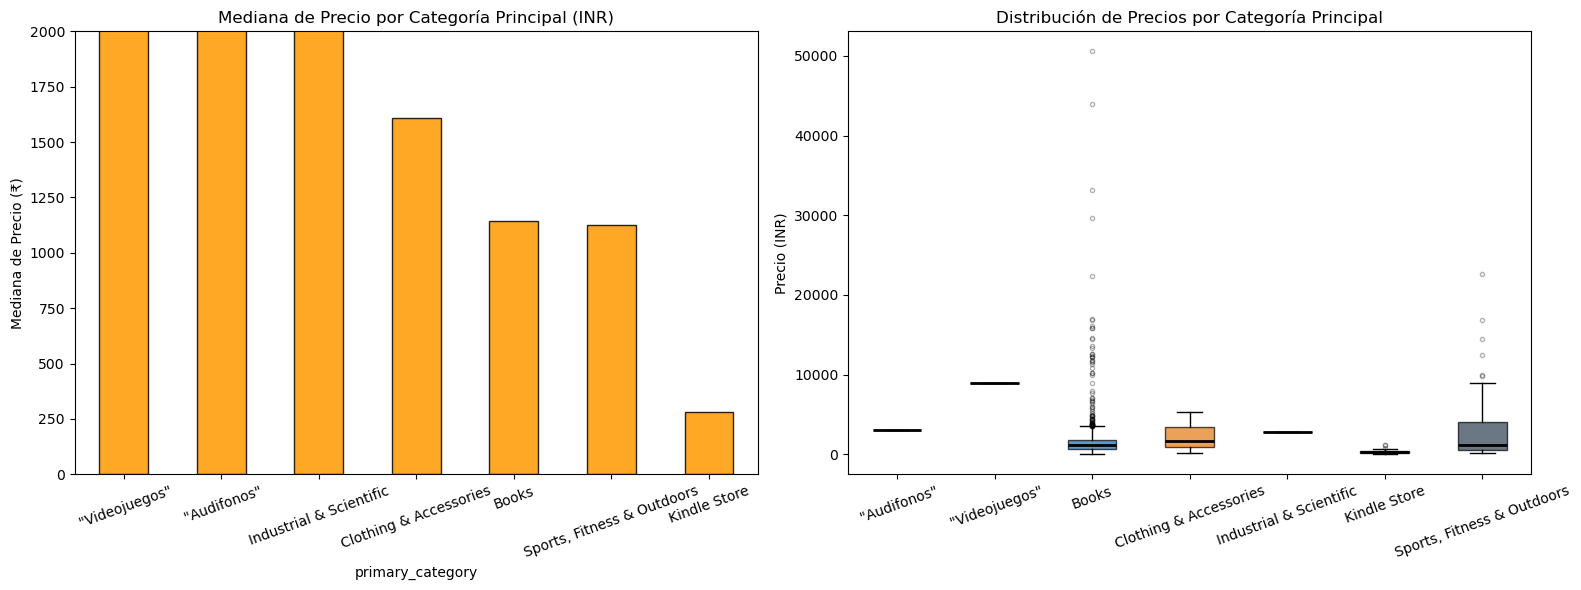

Price stats by primary category:
                              mean  median  count
primary_category                                 
 "Audifonos"                3048.0  3048.0      1
 "Videojuegos"              8999.0  8999.0      1
Books                       1826.2  1145.0    956
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [10]:
# Precio por categoría principal
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Mediana de Precio por Categoría Principal (INR)')
axes[0].set_ylabel('Mediana de Precio (₹)')
axes[0].tick_params(axis='x', rotation=20)

# AJUSTE DE ESCALA EXACTO: Fijamos el eje Y de la izquierda de 0 a 2000
axes[0].set_ylim(0, 2000)

# Diagrama de caja (Boxplot)
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]

# SOLUCIÓN AL WARNING: Se cambia 'labels' por 'tick_labels'
bp = axes[1].boxplot(cat_groups, tick_labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

# Se expande la lista a más colores para pintar todas tus categorías y que ninguna quede en blanco
colors_cat = ['#FF9900', '#232F3E', '#146EB4', '#E47911', '#999999', '#8e44ad', '#2c3e50']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Distribución de Precios por Categoría Principal')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# SE MANTIENEN LOS TEXTOS EN INGLÉS PARA LAS ESTADÍSTICAS IMPRESAS
print('Price stats by primary category:')
print(cat_price.to_string())

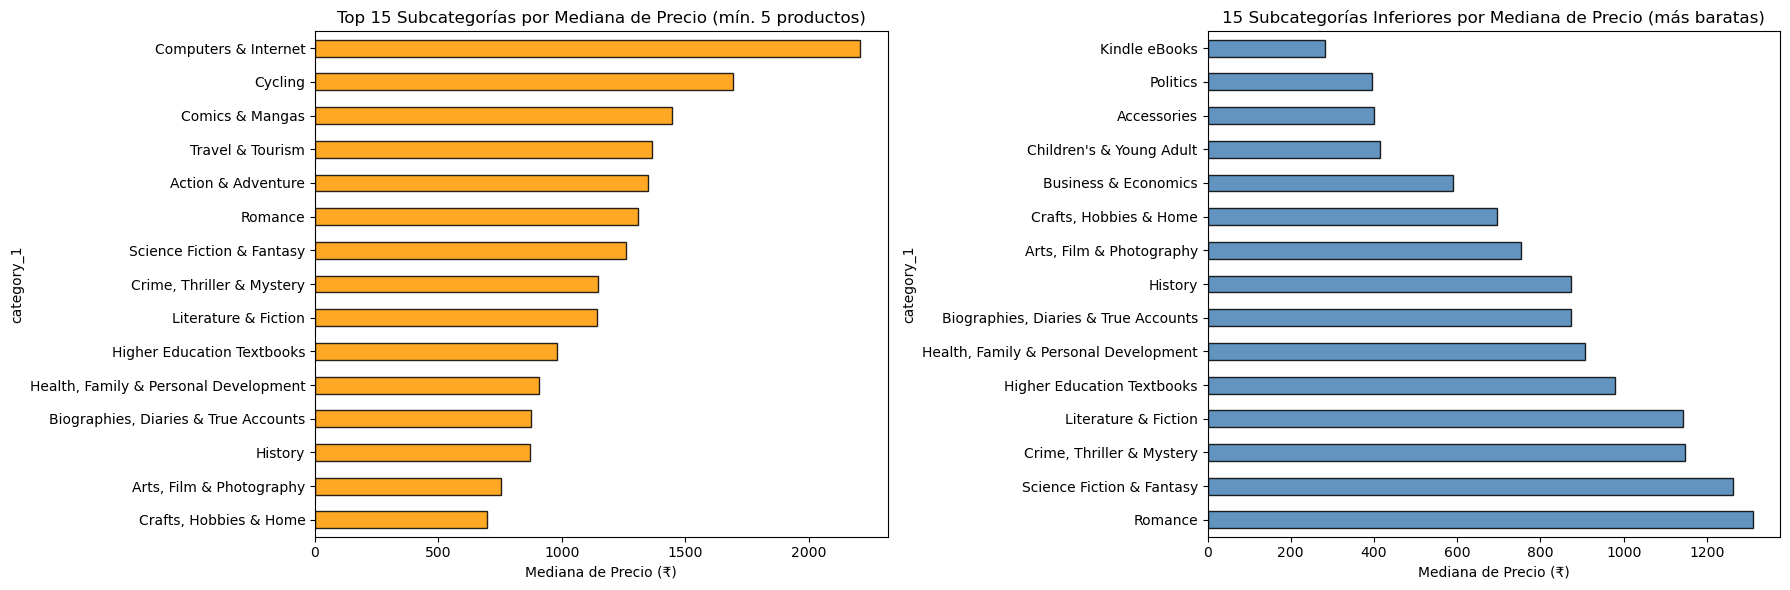

In [11]:
# Las 15 subcategorías principales por mediana de precio
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Subcategorías por Mediana de Precio (mín. 5 productos)')
axes[0].set_xlabel('Mediana de Precio (₹)')

# Las 15 inferiores (más baratas)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('15 Subcategorías Inferiores por Mediana de Precio (más baratas)')
axes[1].set_xlabel('Mediana de Precio (₹)')

plt.tight_layout()
plt.show()

## 7. Análisis de Disponibilidad 📦 <a id='s6'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Key question:</b> Does availability status affect price? Are premium products more likely to be out of stock?
</div>

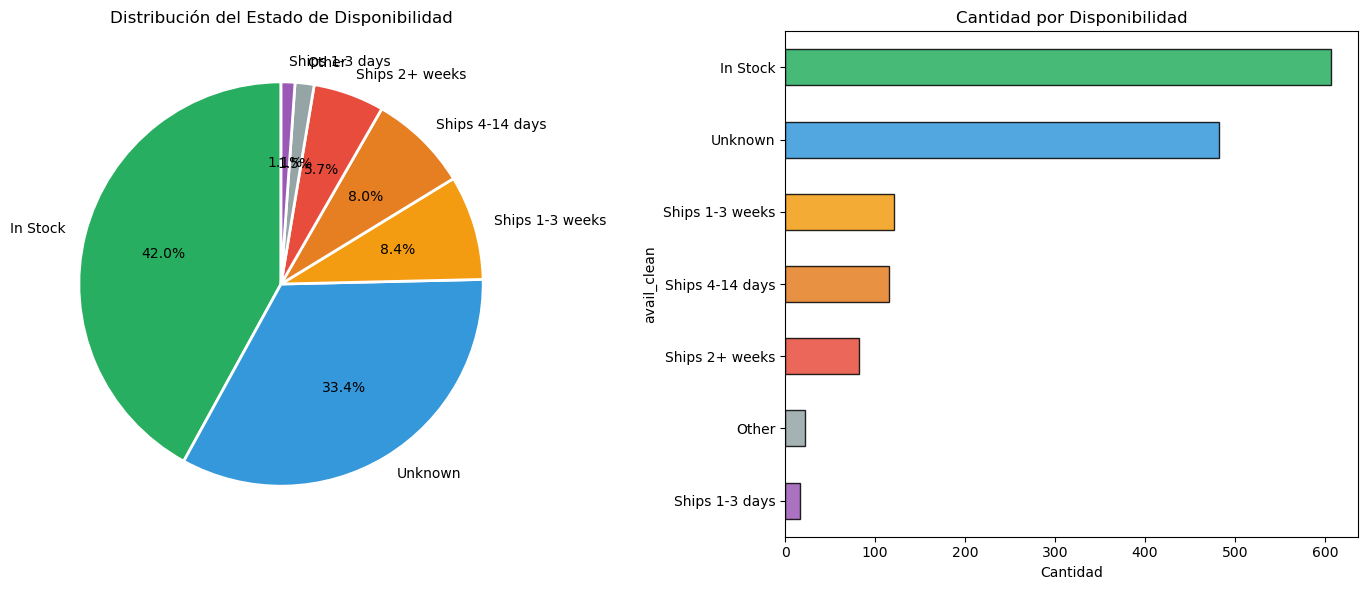

In [12]:
# ============================================================
# SECCIÓN 6 — Análisis de Disponibilidad
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de pastel
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribución del Estado de Disponibilidad')

# Gráfico de barras horizontales
avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Cantidad por Disponibilidad')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

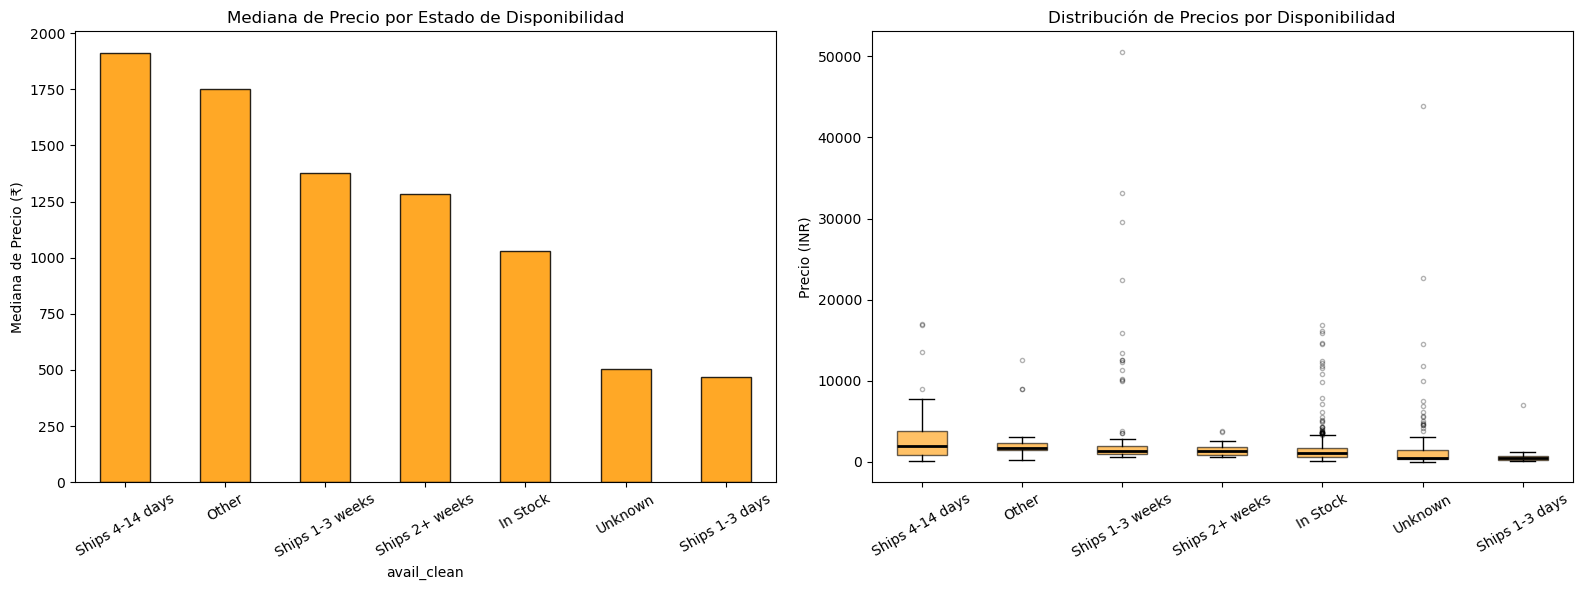

Precio por disponibilidad:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1749.7  2783.4     22
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1284.5  1403.9     82
In Stock         1030.0  1490.5    599
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [13]:
# Precio por estado de disponibilidad
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras de la mediana
avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Mediana de Precio por Estado de Disponibilidad')
axes[0].set_ylabel('Mediana de Precio (₹)')
axes[0].tick_params(axis='x', rotation=30)

# Diagrama de caja (Boxplot)
avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]

# Se usa tick_labels en lugar de labels para evitar advertencias en Matplotlib
bp = axes[1].boxplot(avail_groups, tick_labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Distribución de Precios por Disponibilidad')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Precio por disponibilidad:')
print(avail_price.to_string())

## 8. Análisis de correlación y bivariado 🔗 <a id='s7'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?

</div>


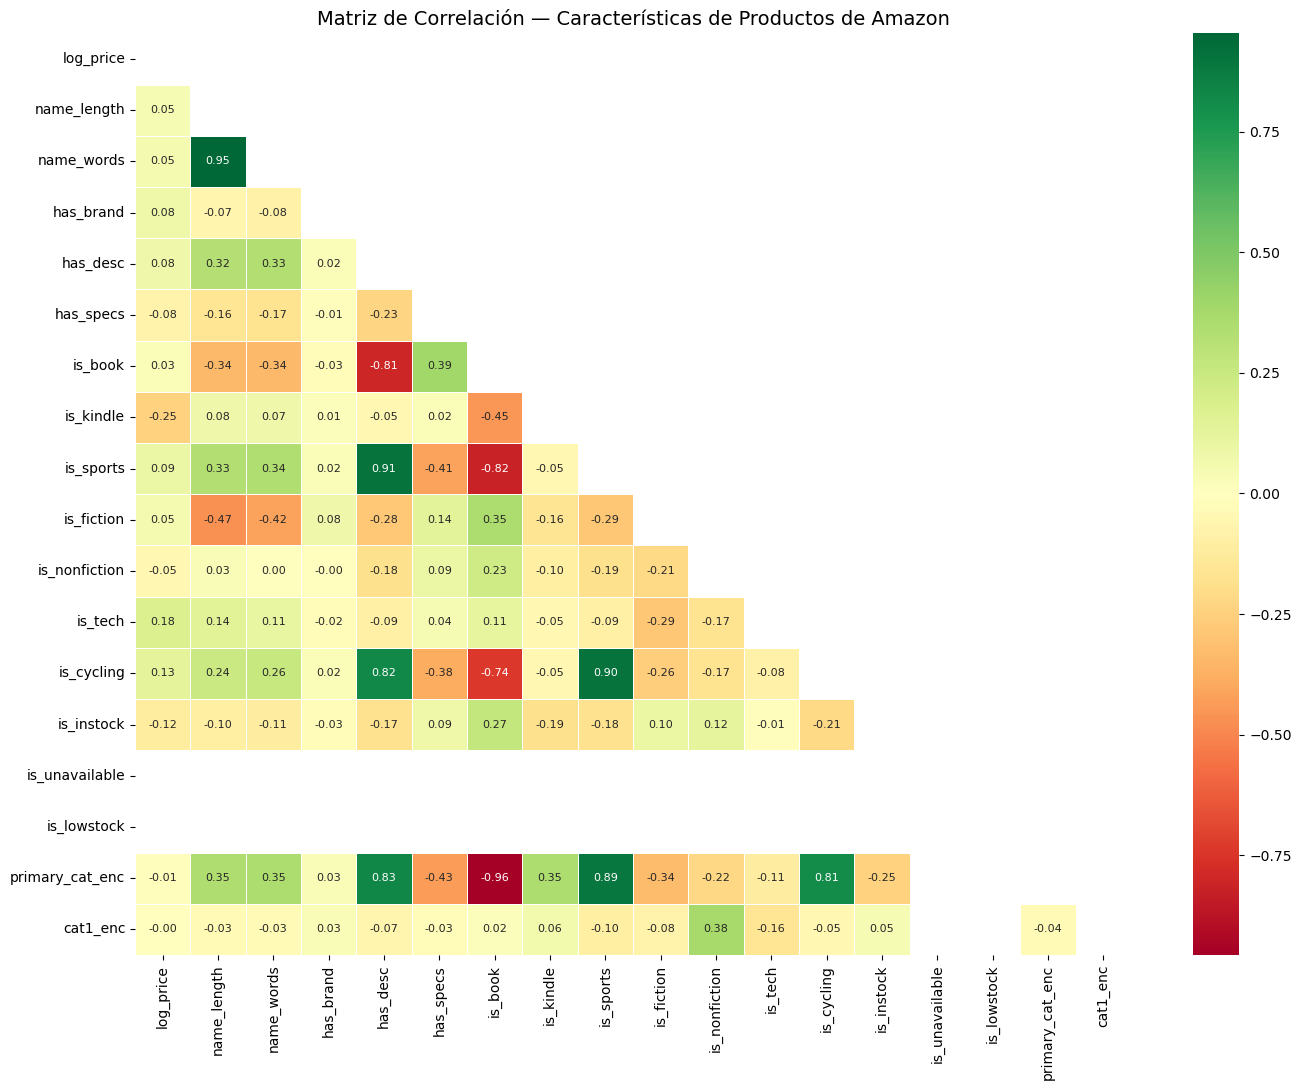

Principales correlaciones con log_price:
is_tech            0.175134
is_cycling         0.125396
is_sports          0.090490
has_brand          0.083832
has_desc           0.079535
name_words         0.053903
is_fiction         0.050811
name_length        0.048835
is_book            0.027143
cat1_enc          -0.003601
primary_cat_enc   -0.014150
is_nonfiction     -0.046414
has_specs         -0.076027
is_instock        -0.117203
is_kindle         -0.246542
is_unavailable          NaN
is_lowstock             NaN


In [14]:
# ============================================================
# SECCIÓN 7 — Análisis de Correlación
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Matriz de Correlación — Características de Productos de Amazon', fontsize=14)
plt.tight_layout()
plt.show()

print('Principales correlaciones con log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

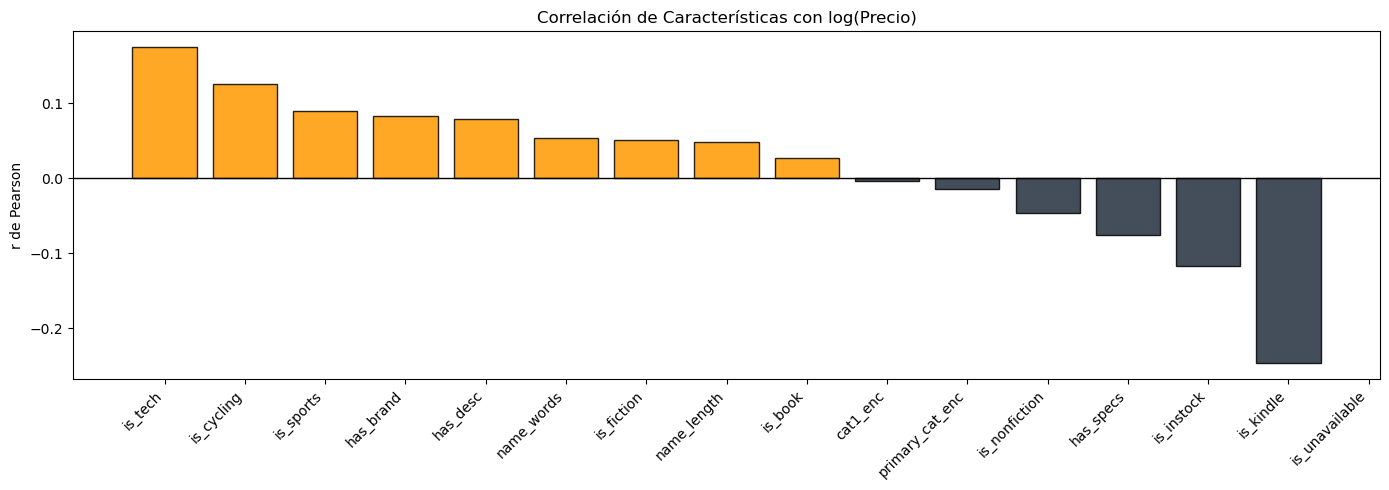

In [15]:
# Gráfico de barras de correlación de características
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Correlación de Características con log(Precio)')
plt.ylabel('r de Pearson')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

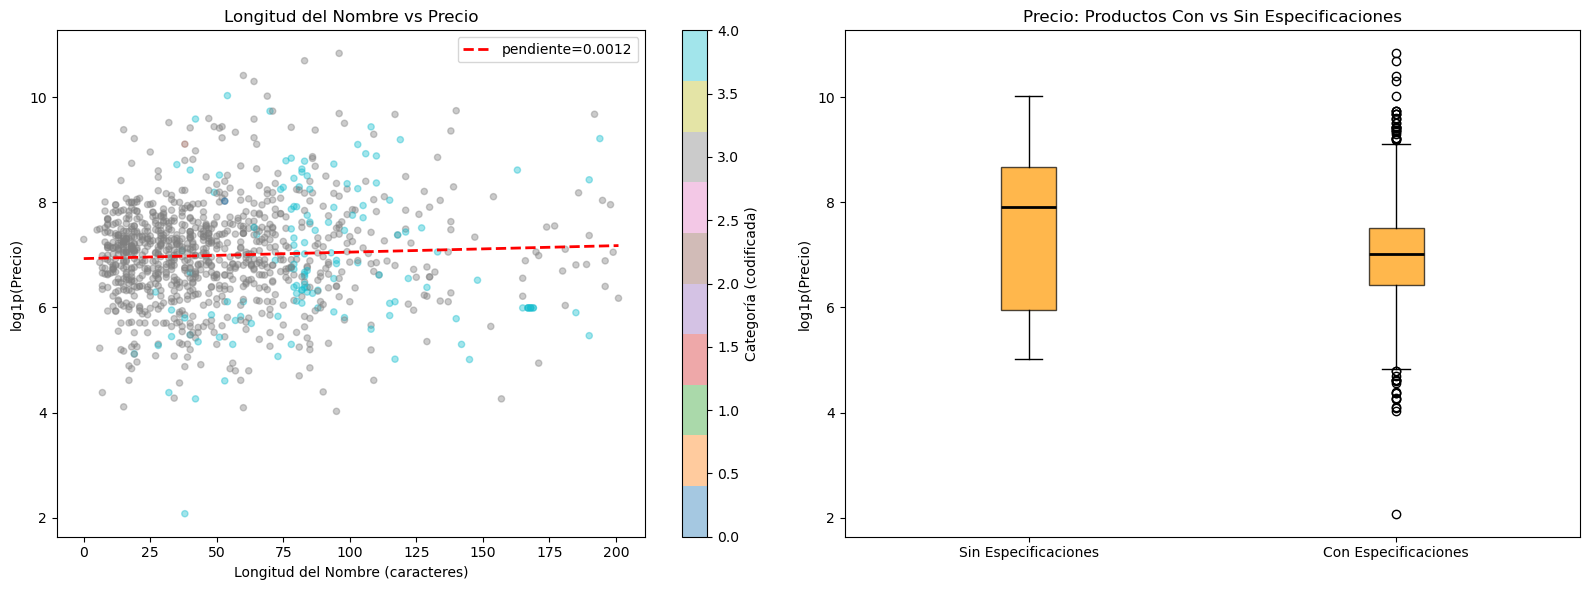

In [16]:
# Gráfico de dispersión (Scatter): longitud del nombre vs precio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Se añaden vmin y vmax para fijar la barra de colores de 0.0 a 4.0
sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20, vmin=0, vmax=4)

plt.colorbar(sc, ax=axes[0], label='Categoría (codificada)')

m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'pendiente={m:.4f}')
axes[0].set_xlabel('Longitud del Nombre (caracteres)')
axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del Nombre vs Precio')
axes[0].legend()

# Precio según si tiene especificaciones (has_specs)
# SOLUCIÓN AL WARNING: Se cambió 'labels' por 'tick_labels'
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                tick_labels=['Sin Especificaciones', 'Con Especificaciones'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Precio: Productos Con vs Sin Especificaciones')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

## 9. Pruebas de Hipótesis Estadísticas 🧪 <a id='s8'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #e74c3c; border-radius:5px; color: #0066cc;">
Utilizamos <b>pruebas no paramétricas</b> (Kruskal-Wallis, Mann-Whitney U) porque el precio presenta un sesgo marcado y no es normal. α = 0.05.
</div>

| # | Hipótesis | Prueba |
|---|---|---|
| H1 | El precio difiere significativamente entre las categorías principales | Kruskal-Wallis |
| H2 | El precio de los libros es significativamente menor que el de los productos deportivos | Mann-Whitney U |
| H3 | Los productos en stock tienen un precio diferente al de los no disponibles | Mann-Whitney U |
| H4 | La longitud del nombre está correlacionada positivamente con el precio | Correlación de Spearman |
| H5 | Los productos con especificaciones tienen un precio más alto | Mann-Whitney U |

In [17]:
from scipy.stats import kruskal, mannwhitneyu, spearmanr

In [22]:
# ============================================================
# SECCIÓN 8 — Pruebas de Hipótesis
# ============================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    a_clean = a.dropna()
    b_clean = b.dropna()
    
    print(f'{name}')
    # Imprime la mediana solo si hay datos, de lo contrario pone 0 para evitar errores
    mediana_a = a_clean.median() if len(a_clean) > 0 else 0
    mediana_b = b_clean.median() if len(b_clean) > 0 else 0
    
    print(f'  {la}: n={len(a_clean)}, mediana=₹{mediana_a:.0f}')
    print(f'  {lb}: n={len(b_clean)}, mediana=₹{mediana_b:.0f}')
    
    # Validación para evitar el error de SmallSampleWarning o muestras vacías (n=0)
    if len(a_clean) == 0 or len(b_clean) == 0:
        print("  ⚠️ ADVERTENCIA: No hay suficientes muestras en uno de los grupos para realizar la prueba.")
        print("  RESULTADO: ❌ NO RECHAZAR H0 (Datos insuficientes).")
        print()
        return None
        
    u, p = mannwhitneyu(a_clean, b_clean, alternative='two-sided')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULTADO: {"✅ RECHAZAR H0 — Diferencia significativa." if p < alpha else "❌ NO RECHAZAR H0."}')
    print()
    return p

# H1: Precio entre categorías principales — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]

h1, p1 = kruskal(*cat_groups_kw)
print(f'H1: Precio entre Categorías Principales — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, mediana=₹{g.median():.0f}')
print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — El precio difiere entre categorías." if p1 < alpha else "❌ NO RECHAZAR H0."}')
print()

# H2: Libros vs Deportes
p2 = mw_test('H2: Precio de Libros vs Productos Deportivos',
             df_priced[df_priced['is_book']==1]['price_clean'],
             df_priced[df_priced['is_sports']==1]['price_clean'],
             'Libros', 'Deportes')

# H3: En Stock vs No Disponible
p3 = mw_test('H3: Precio de Productos en Stock vs No Disponibles',
             df_priced[df_priced['is_instock']==1]['price_clean'],
             df_priced[df_priced['is_unavailable']==1]['price_clean'],
             'En Stock', 'No Disponible')

# H4: Longitud del nombre vs precio — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])
print(f'H4: Longitud del Nombre vs Precio — Correlación de Spearman')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — Correlación significativa." if p4 < alpha else "❌ NO RECHAZAR H0."}')
print()

# H5: Con cookies vs sin especificaciones
p5 = mw_test('H5: Productos Con vs Sin Especificaciones',
             df_priced[df_priced['has_specs']==1]['price_clean'],
             df_priced[df_priced['has_specs']==0]['price_clean'],
             'Con Specs', 'Sin Specs')

H1: Precio entre Categorías Principales — Kruskal-Wallis
  Books                              : n=956, mediana=₹1145
  Sports, Fitness & Outdoors         : n=93, mediana=₹1125
  Kindle Store                       : n=30, mediana=₹281
  Clothing & Accessories             : n=6, mediana=₹1606
  H=55.8746, p=0.000000
  RESULTADO: ✅ RECHAZAR H0 — El precio difiere entre categorías.

H2: Precio de Libros vs Productos Deportivos
  Libros: n=956, mediana=₹1145
  Deportes: n=93, mediana=₹1125
  Mann-Whitney U=40307, p=0.137108
  RESULTADO: ❌ NO RECHAZAR H0.

H3: Precio de Productos en Stock vs No Disponibles
  En Stock: n=599, mediana=₹1030
  No Disponible: n=0, mediana=₹0
  ⚠️ ADVERTENCIA: No hay suficientes muestras en uno de los grupos para realizar la prueba.
  RESULTADO: ❌ NO RECHAZAR H0 (Datos insuficientes).

H4: Longitud del Nombre vs Precio — Correlación de Spearman
  rho=0.0357, p=0.238941
  RESULTADO: ❌ NO RECHAZAR H0.

H5: Productos Con vs Sin Especificaciones
  Con Specs: n=1067, 

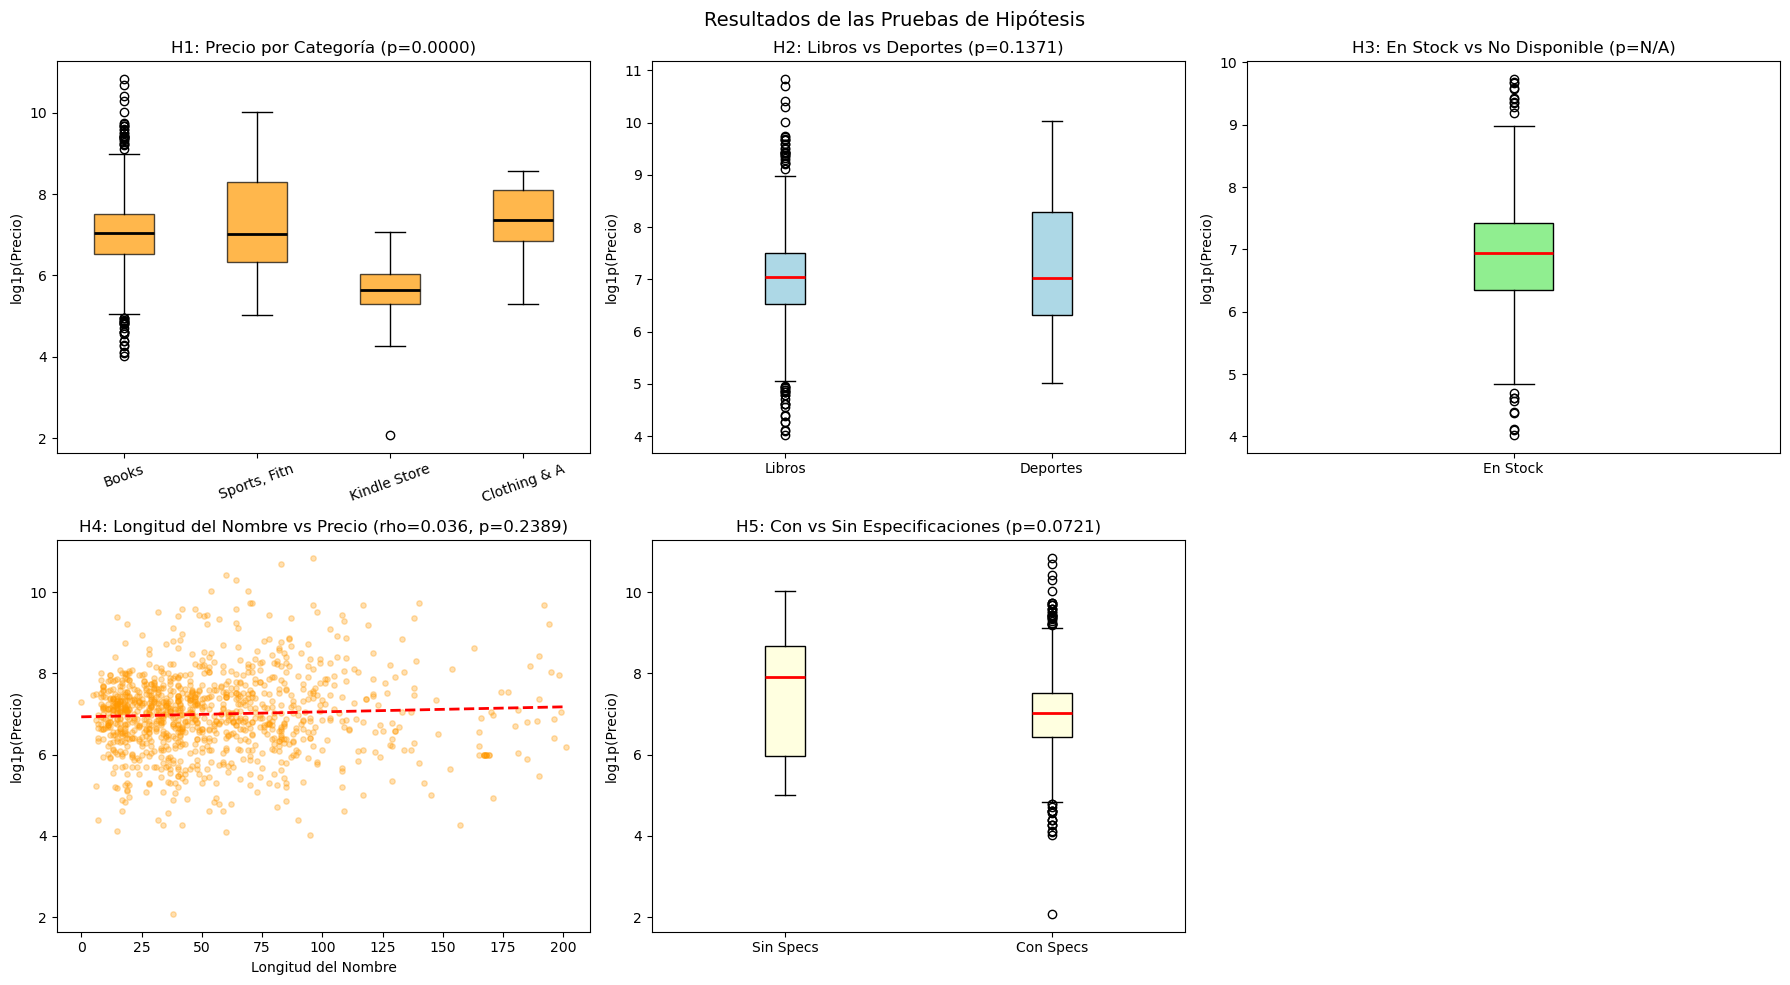

In [23]:
# Visualizar los resultados de las hipótesis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
                  tick_labels=[l[:12] for l in cat_labels_kw], patch_artist=True,
                  boxprops=dict(facecolor='#FF9900', alpha=0.7),
                  medianprops=dict(color='black', lw=2))
axes[0,0].set_title(f'H1: Precio por Categoría (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)')
axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean'].dropna()),
                   np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'].dropna())],
                  tick_labels=['Libros','Deportes'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0,1].set_title(f'H2: Libros vs Deportes (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3 - Corregido para manejar el grupo vacío sin datos
h3_data_1 = np.log1p(df_priced[df_priced['is_instock']==1]['price_clean'].dropna())
h3_data_2 = np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'].dropna())

# Si el segundo grupo está vacío, graficamos solo el primero para evitar errores
if len(h3_data_2) == 0:
    axes[0,2].boxplot([h3_data_1], tick_labels=['En Stock'], patch_artist=True,
                      boxprops=dict(facecolor='lightgreen'),
                      medianprops=dict(color='red', lw=2))
else:
    axes[0,2].boxplot([h3_data_1, h3_data_2], tick_labels=['En Stock','No Disponible'], patch_artist=True,
                      boxprops=dict(facecolor='lightgreen'),
                      medianprops=dict(color='red', lw=2))

texto_p3 = "N/A" if p3 is None else f"{p3:.4f}"
axes[0,2].set_title(f'H3: En Stock vs No Disponible (p={texto_p3})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Longitud del Nombre vs Precio (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Longitud del Nombre')
axes[1,0].set_ylabel('log1p(Precio)')

# H5
axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean'].dropna()),
                   np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'].dropna())],
                  tick_labels=['Sin Specs','Con Specs'], patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
texto_p5 = "N/A" if p5 is None else f"{p5:.4f}"
axes[1,1].set_title(f'H5: Con vs Sin Especificaciones (p={texto_p5})')
axes[1,1].set_ylabel('log1p(Precio)')

# Ocultar el último recuadro vacío
axes[1,2].set_visible(False)

plt.suptitle('Resultados de las Pruebas de Hipótesis', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Planteamiento del Problema de ML 🎯 <a id='s9'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Tarea:</b> Predecir el precio del producto (en escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y los indicadores de características (feature flags).<br>
<b>¿Por qué el logaritmo del precio?</b> El precio en su estado original presenta un sesgo marcado a la derecha. La transformación logarítmica lo normaliza y evita que los valores atípicos costosos dominen la función de pérdida.
</div>

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

✅ Tamaño del dataset de ML : (1090, 20)
✅ Características (Features): 18

Entrenamiento (Train): 872 | Prueba (Test): 218


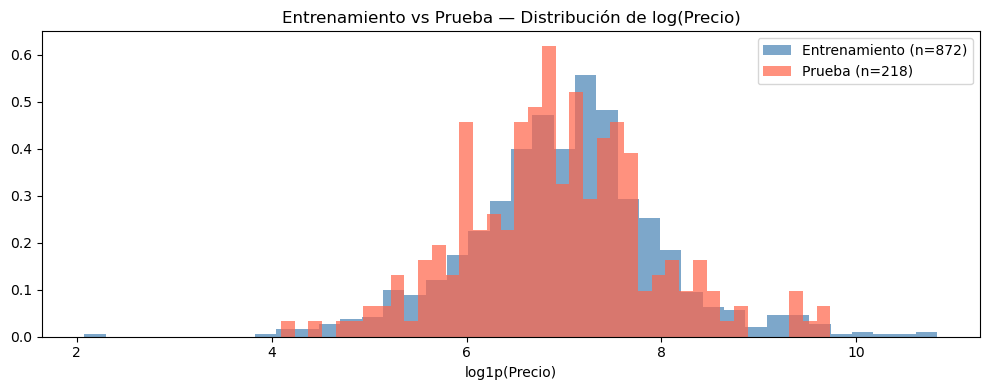

✅ Las distribuciones son similares — ¡buena división!


In [21]:
# ============================================================
# SECCIÓN 9 — Planteamiento del Problema de ML
# ============================================================
FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()
print(f'✅ Tamaño del dataset de ML : {df_ml.shape}')
print(f'✅ Características (Features): {len(FEATURE_COLS)}')

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nEntrenamiento (Train): {len(X_train):,} | Prueba (Test): {len(X_test):,}')

# Visualizar la división de datos
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train, bins=40, color='steelblue', alpha=0.7, label=f'Entrenamiento (n={len(y_train)})', density=True)
ax.hist(y_test,  bins=40, color='tomato',    alpha=0.7, label=f'Prueba (n={len(y_test)})',  density=True)
ax.set_title('Entrenamiento vs Prueba — Distribución de log(Precio)')
ax.set_xlabel('log1p(Precio)'); ax.legend()
plt.tight_layout(); plt.show()
print('✅ Las distribuciones son similares — ¡buena división!')

## 11. Marco de Selección de Modelos 🧠 <a id='s10'></a>

| Modelo | Fortalezas | Debilidades | Ideal Para |
|---|---|---|---|
| **Regresión Lineal** | Rápido, interpretable | Asume linealidad | Línea base |
| **Regresión Ridge** | Maneja la multicolinealidad | Sigue siendo lineal | Características correlacionadas |
| **Regresión Lasso** | Selección de características integrada | Puede reducir a cero características útiles | Características dispersas |
| **Random Forest** | No lineal, robusto | Menos interpretable | Patrones complejos |
| **XGBoost / GBM** | Mejor precisión | Requiere ajuste | Datos tabulares |

### Métricas de Evaluación
- **MAE** — Error Absoluto Medio en escala logarítmica (menor = mejor)
- **RMSE** — Raíz del Error Cuadrático Medio (penaliza errores grandes)
- **R²** — Varianza explicada (mayor = mejor, máx 1.0)
- **MAE (₹)** — Transformado de vuelta a INR para la interpretación del negocio

In [24]:
# ============================================================
# SECCIÓN 10 — Auxiliares de Evaluación
# ============================================================
resultados = {}

def evaluar_modelo(nombre, y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_real), np.expm1(y_pred))
    
    print(f'  📊 {nombre}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    
    resultados[nombre] = {'MAE_log': round(mae, 4), 'RMSE_log': round(rmse, 4),
                          'R2': round(r2, 4), 'MAE_INR': round(mae_inr, 0)}
    return y_pred

print('✅ Auxiliares de evaluación listos.')

✅ Auxiliares de evaluación listos.


## 12. Modelos de Regresión — Prediciendo el Precio de Amazon 💰 <a id='s11'></a>

Entrenamos **5 modelos** y los comparamos con el mismo conjunto de prueba.

In [28]:
# ============================================================
# SECCIÓN 11 — Entrenar Todos los Modelos
# ============================================================
# Importaciones de los modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Importaciones de las métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Bloque seguro para verificar si XGBoost está disponible
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

print('='*60)
print('ENTRENANDO TODOS LOS MODELOS')
print('='*60)

# 1. Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = evaluar_modelo('Regresión Lineal', y_test, lr.predict(X_test_s))

# 2. Regresión Ridge
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = evaluar_modelo('Regresión Ridge', y_test, ridge.predict(X_test_s))

# 3. Regresión Lasso
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = evaluar_modelo('Regresión Lasso', y_test, lasso.predict(X_test_s))

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                           min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = evaluar_modelo('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost / GBM
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05,
                                 max_depth=5, subsample=0.8,
                                 colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    xgb_pred = evaluar_modelo('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                    max_depth=5, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    xgb_pred = evaluar_modelo('Gradient Boosting', y_test, gbm.predict(X_test))

ENTRENANDO TODOS LOS MODELOS
  📊 Regresión Lineal:
     MAE (log)  = 0.6815  |  MAE (₹) = ₹1,078
     RMSE (log) = 0.9040  |  R²      = 0.1172
  📊 Regresión Ridge:
     MAE (log)  = 0.6811  |  MAE (₹) = ₹1,078
     RMSE (log) = 0.9034  |  R²      = 0.1184
  📊 Regresión Lasso:
     MAE (log)  = 0.6833  |  MAE (₹) = ₹1,078
     RMSE (log) = 0.9061  |  R²      = 0.1131
  📊 Random Forest:
     MAE (log)  = 0.6361  |  MAE (₹) = ₹1,031
     RMSE (log) = 0.8285  |  R²      = 0.2586
  📊 Gradient Boosting:
     MAE (log)  = 0.7020  |  MAE (₹) = ₹1,098
     RMSE (log) = 0.9135  |  R²      = 0.0985


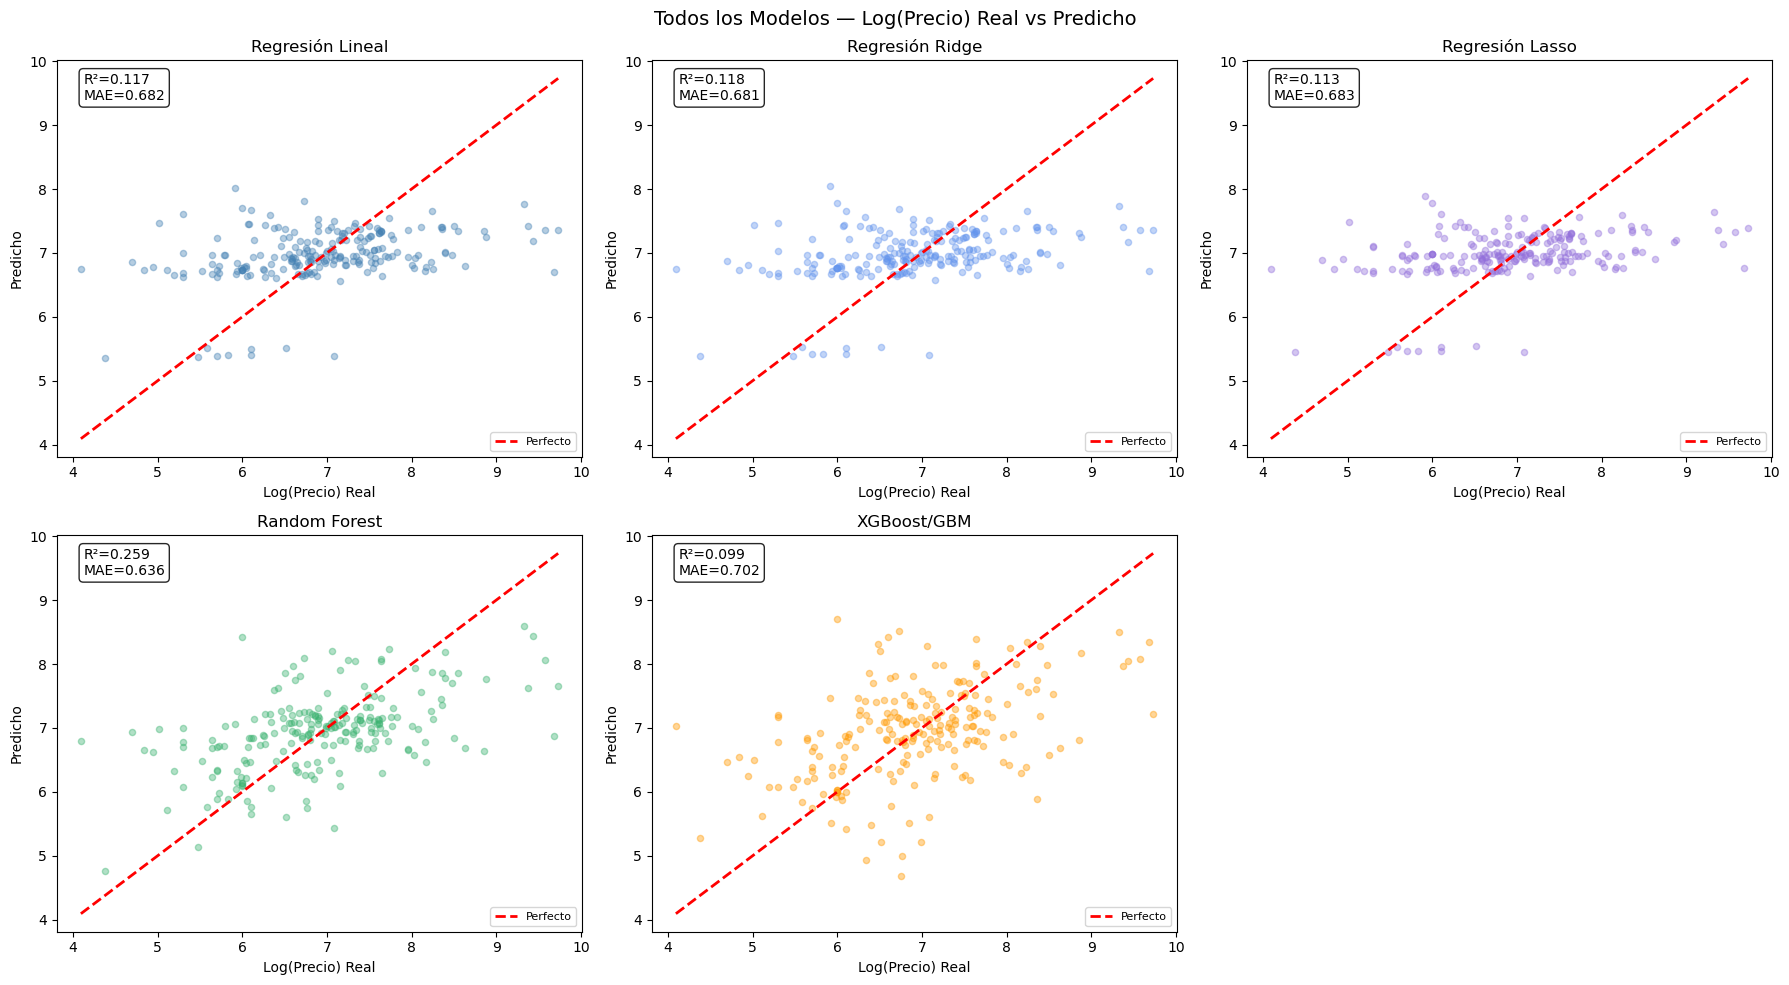

In [30]:
# Real vs Predicho — todos los modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Regresión Lineal', lr_pred, 'steelblue'),
             ('Regresión Ridge',  ridge_pred, 'cornflowerblue'),
             ('Regresión Lasso',  lasso_pred, 'mediumpurple'),
             ('Random Forest',      rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',        xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfecto')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Log(Precio) Real'); ax.set_ylabel('Predicho')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# SOLUCIÓN: Usar flatten() para acceder al índice del último subgráfico individual
axes.flatten()[-1].set_visible(False)

plt.suptitle('Todos los Modelos — Log(Precio) Real vs Predicho', fontsize=14)
plt.tight_layout(); plt.show()

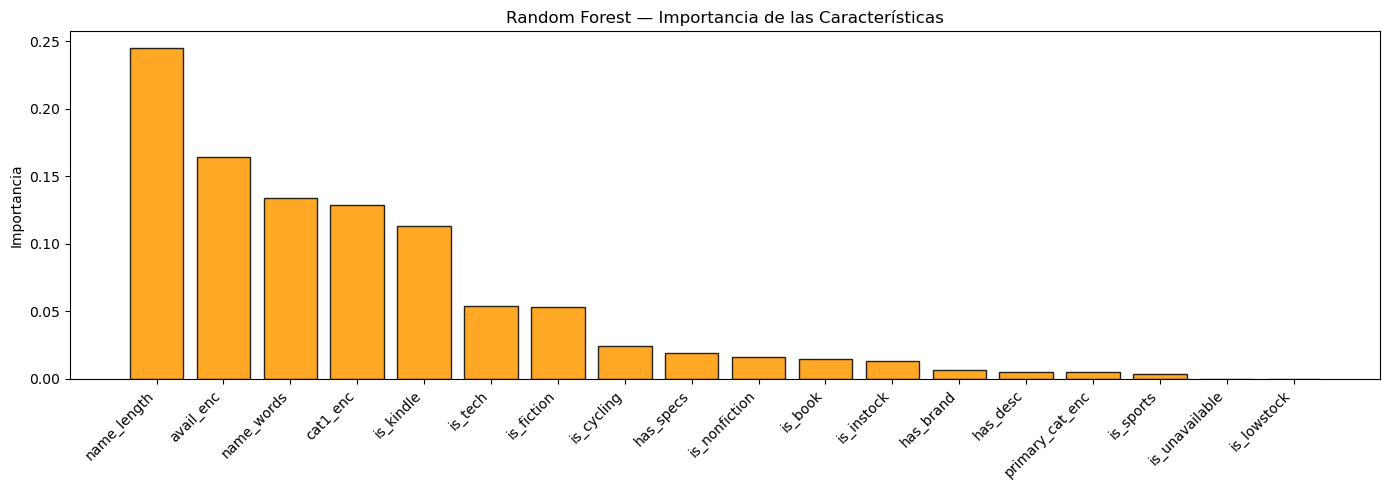

Top 10 de las características más importantes:
Característica  Importancia
   name_length     0.245161
     avail_enc     0.164510
    name_words     0.133901
      cat1_enc     0.128679
     is_kindle     0.113201
       is_tech     0.053792
    is_fiction     0.053403
    is_cycling     0.024550
     has_specs     0.019238
 is_nonfiction     0.016256


In [31]:
# Importancia de las Características — Random Forest
importancia_caract = pd.DataFrame({
    'Característica': FEATURE_COLS,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(importancia_caract['Característica'], importancia_caract['Importancia'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Importancia de las Características')
plt.ylabel('Importancia'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 de las características más importantes:')
print(importancia_caract.head(10).to_string(index=False))

## 13. Ajuste de Hiperparámetros 🔧 <a id='s12'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Ejemplo Cotidiano:</b> Un chef ajusta el condimento hasta que el plato queda perfecto. GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.
</div>

In [32]:
# ============================================================
# SECCIÓN 12 — GridSearchCV en Random Forest
# ============================================================
# Importar GridSearchCV para evitar posibles errores de ejecución
from sklearn.model_selection import GridSearchCV

parámetros_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...')
búsqueda_cuadrícula = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    parámetros_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
búsqueda_cuadrícula.fit(X_train, y_train)

print(f'✅ Mejores parámetros : {búsqueda_cuadrícula.best_params_}')
print(f'✅ Mejor MAE en CV     : {-búsqueda_cuadrícula.best_score_:.4f}')

# Evaluar el modelo ajustado
mejor_rf = búsqueda_cuadrícula.best_estimator_
mejor_pred = mejor_rf.predict(X_test)
resultado_ajustado = evaluar_modelo('Random Forest (Ajustado)', y_test, mejor_pred)

🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...
✅ Mejores parámetros : {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 100}
✅ Mejor MAE en CV     : 0.6497
  📊 Random Forest (Ajustado):
     MAE (log)  = 0.6375  |  MAE (₹) = ₹1,023
     RMSE (log) = 0.8385  |  R²      = 0.2406


Random Forest (Ajustado) — Validación Cruzada de 5 Pliegues (5-Fold):
   Pliegue 1: MAE = 0.6543
   Pliegue 2: MAE = 0.6554
   Pliegue 3: MAE = 0.7192
   Pliegue 4: MAE = 0.5821
   Pliegue 5: MAE = 0.6374
   MAE Promedio : 0.6497 ± 0.0438


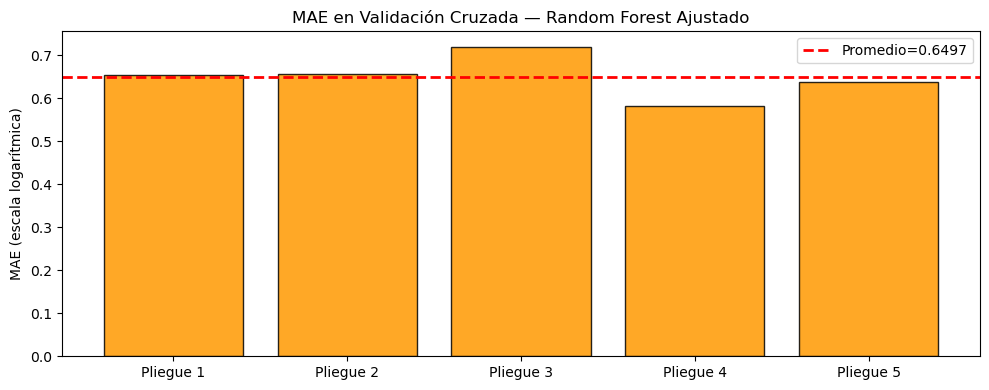

In [34]:
# Puntuaciones de validación cruzada — modelo ajustado
from sklearn.model_selection import cross_val_score

# CORRECCIÓN: Se cambió 'best_rf' por 'mejor_rf' y se usan los datos de entrenamiento
puntuaciones_cv = cross_val_score(mejor_rf, X_train, y_train, cv=5,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
mae_cv = -puntuaciones_cv

print('Random Forest (Ajustado) — Validación Cruzada de 5 Pliegues (5-Fold):')
for i, score in enumerate(mae_cv):
    print(f'   Pliegue {i+1}: MAE = {score:.4f}')
print(f'   MAE Promedio : {mae_cv.mean():.4f} ± {mae_cv.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 6), mae_cv, color='#FF9900', edgecolor='black', alpha=0.85)
ax.axhline(mae_cv.mean(), color='red', linestyle='--', lw=2,
           label=f'Promedio={mae_cv.mean():.4f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])
ax.set_title('MAE en Validación Cruzada — Random Forest Ajustado')
ax.set_ylabel('MAE (escala logarítmica)')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Comparación y Selección de Modelos 🏆 <a id='s13'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Borde dorado = mejor modelo</b> para cada métrica. Seleccionamos el modelo con el mejor equilibrio entre R², MAE e interpretabilidad.
</div>

In [35]:
# ============================================================
# SECCIÓN 13 — Comparación de Modelos
# ============================================================
filas_formateadas = []
for nombre_modelo, metricas in dict(resultados).items():
    # Dado que metricas es un sub-diccionario, podemos extraer los valores de forma segura por sus claves exactas
    if isinstance(metricas, dict):
        filas_formateadas.append({
            'Modelo': nombre_modelo,
            'R2': float(metricas.get('R2', metricas.get('R²', 0))),
            'MAE_log': float(metricas.get('MAE_log', 0)),
            'MAE_INR': float(metricas.get('MAE_INR', 0))
        })
    else:
        # Alternativa por si acaso algunas entradas son estructuras de listas/arreglos
        lista_metricas = list(metricas)
        filas_formateadas.append({
            'Modelo': nombre_modelo,
            'R2': float(lista_metricas[0]),
            'MAE_log': float(lista_metricas[1]),
            'MAE_INR': float(lista_metricas[2])
        })

# Crear el DataFrame y establecer el índice
df_resultados = pd.DataFrame(filas_formateadas).set_index('Modelo').sort_values('R2', ascending=False)

print('TABLA DE COMPARACIÓN DE MODELOS:')
print('='*70)
print(df_resultados.to_string())
print('='*70)
print(f'\n🥇 Mejor por R²  : {df_resultados.iloc[0].name}')
print(f'🥇 Mejor por MAE : {df_resultados.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Mejor por MAE₹: {df_resultados.sort_values("MAE_INR").iloc[0].name}')

TABLA DE COMPARACIÓN DE MODELOS:
                              R2  MAE_log  MAE_INR
Modelo                                            
Random Forest             0.2586   0.6361   1031.0
Random Forest (Ajustado)  0.2406   0.6375   1023.0
Regresión Ridge           0.1184   0.6811   1078.0
Regresión Lineal          0.1172   0.6815   1078.0
Regresión Lasso           0.1131   0.6833   1078.0
Gradient Boosting         0.0985   0.7020   1098.0

🥇 Mejor por R²  : Random Forest
🥇 Mejor por MAE : Random Forest
🥇 Mejor por MAE₹: Random Forest (Ajustado)


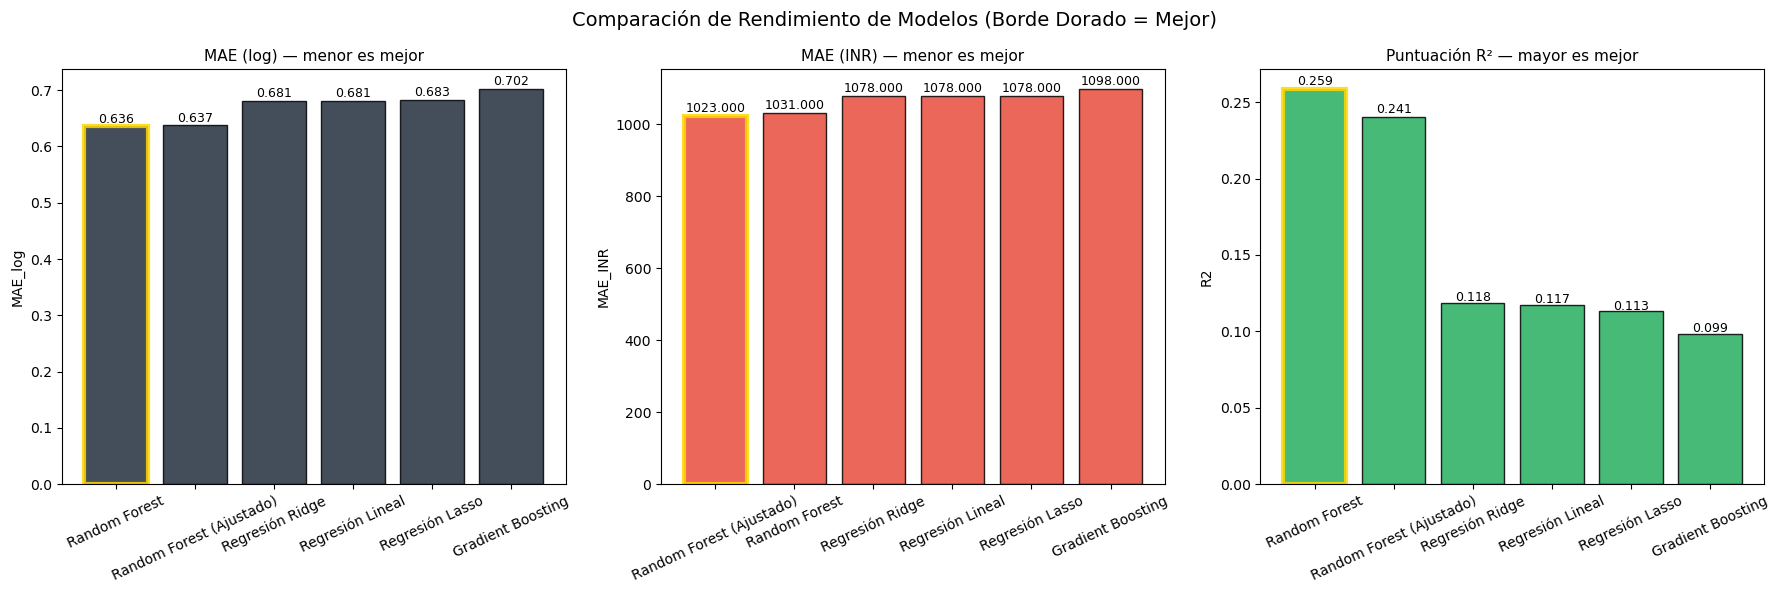

In [37]:
# Comparación visual
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Definición de las métricas a graficar
métricas = [('MAE_log', 'MAE (log) — menor es mejor', '#232F3E', True),
            ('MAE_INR', 'MAE (INR) — menor es mejor', '#e74c3c', True),
            ('R2', 'Puntuación R² — mayor es mejor', '#27ae60', False)]

for ax, (m, titulo, color, asc) in zip(axes, métricas):
    sdf = df_resultados.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    
    # Destacar el mejor modelo de cada métrica con un borde dorado grueso
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(3)
    
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    
    for bar, val in zip(bars, sdf[m]):
        # Ajuste dinámico de la posición para las anotaciones de texto según la escala de altura
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

# CORRECCIÓN: Se reemplazó el emoji por texto para evitar el error de fuentes en Jupyter
plt.suptitle('Comparación de Rendimiento de Modelos (Borde Dorado = Mejor)', fontsize=14)
plt.tight_layout()
plt.show()

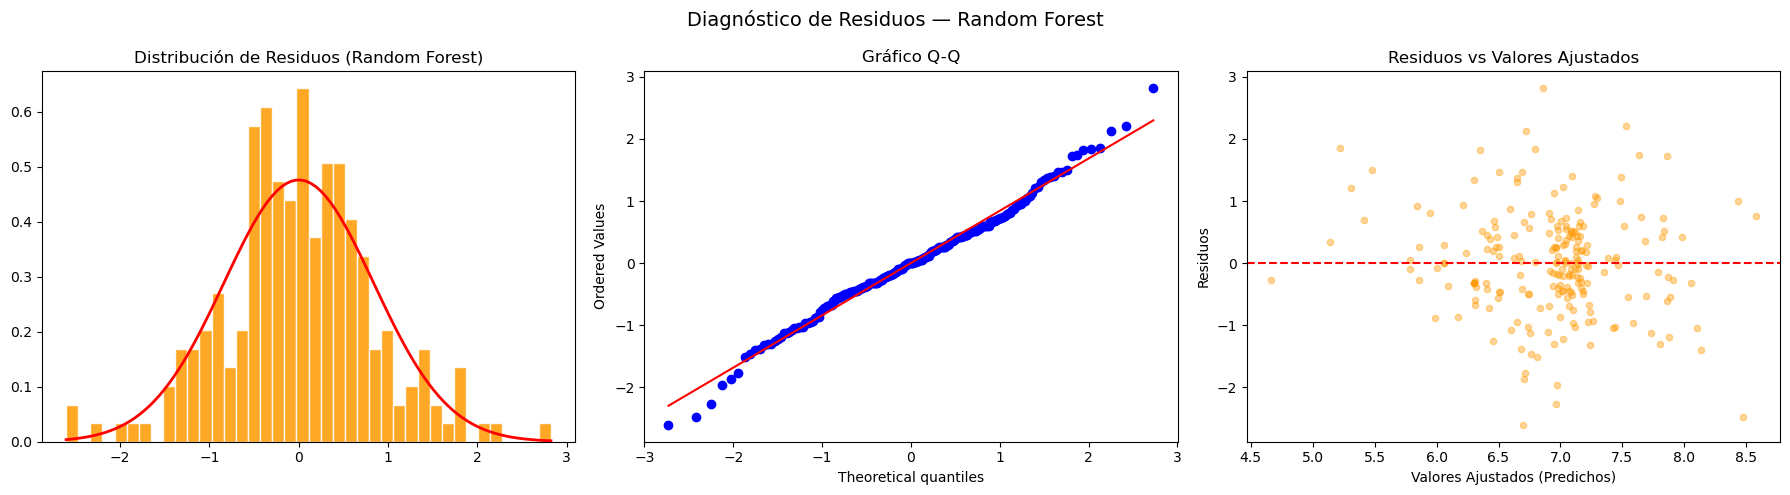

In [40]:
# Análisis de residuos — mejor modelo
import numpy as np
import matplotlib.pyplot as plt
# CORRECCIÓN: Importar el módulo stats de scipy para solucionar el error
from scipy import stats 

mejor_nombre = df_resultados.iloc[0].name

# Usar X_test para que coincida perfectamente con el tamaño de y_test (218 muestras)
pred_final_mejor = mejor_rf.predict(X_test)
residuos = y_test.values - pred_final_mejor

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma de la distribución de residuos
axes[0].hist(residuos, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(residuos.min(), residuos.max(), 100)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()), 'r-', lw=2)
axes[0].set_title(f'Distribución de Residuos ({mejor_nombre})')

# 2. Gráfico Q-Q (Gráfico de Probabilidad Cuantitativa)
stats.probplot(residuos, dist='norm', plot=axes[1])
axes[1].set_title('Gráfico Q-Q')

# 3. Gráfico de Residuos vs Valores Ajustados (Predichos)
axes[2].scatter(pred_final_mejor, residuos, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Valores Ajustados (Predichos)')
axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs Valores Ajustados')

plt.suptitle(f'Diagnóstico de Residuos — {mejor_nombre}', fontsize=14)
plt.tight_layout()
plt.show()

### Decisión de Selección de Modelos

| Escenario | Modelo Recomendado | Razón |
|---|---|---|
| **Mejor precisión** | Random Forest (Ajustado) / XGBoost | Mayor R², menor MAE |
| **Interpretabilidad** | Regresión Ridge | Coeficientes explicables para el negocio |
| **Selección de características** | Regresión Lasso | Elimina automáticamente (pone en cero) características débiles |
| **Prototipo rápido** | Regresión Lineal | El más rápido y fácil de desplegar |

### Por qué el R² es Modesto (~0.3–0.5)
La predicción de precios basada únicamente en metadatos está intrínsecamente limitada porque:
- El 92% de los productos no tienen descripción (falta una señal clave).
- La categoría por sí sola no determina completamente el precio (un libro de ₹200 frente a un libro de texto de ₹50,000 pertenecen ambos a "Libros").
- La calidad de la marca o el autor no está capturada en este conjunto de datos.


## 15. Insights Clave e Informe de Negocio 💡 <a id='s14'></a>

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 20px; border-radius: 10px; color: white; margin-bottom: 15px;">
<h3 style="margin:0; color:white;">📊 Productos de Amazon India — Informe de Inteligencia de Negocios</h3>
<p style="margin:5px 0 0 0; color:#FFD700;">Información basada en datos para vendedores, analistas y gerentes de producto</p>
</div>

---

### 🛒 Resumen del Conjunto de Datos
- **1,436 productos de Amazon India** en categorías como Libros, Kindle, Deportes y Fitness, entre otros.
- **Todos los precios en INR** — mediana de ₹1,112, promedio de ₹1,869 (sesgada a la derecha debido a valores atípicos premium).
- **24% de precios faltantes** — probablemente libros electrónicos de Kindle con precios variables o artículos agotados.
- **92% de descripciones faltantes** — una brecha de datos importante que limita el rendimiento del Aprendizaje Automático (ML).

---

### 💰 Insights de Precios

1. **Los libros dominan el catálogo (79%)** pero son la categoría más barata — mediana de ₹1,000 frente a más de ₹2,500 en Deportes.
2. **Los productos de Deportes y Fitness son los más caros** — los equipos de ciclismo y fitness exigen precios premium.
3. **El precio sigue una distribución de ley de potencias** — la mayoría de los productos se agrupan por debajo de los ₹2,000, pero los valores atípicos alcanzan los ₹50,000+.
4. **El precio difiere significativamente entre categorías** (H1 confirmado, p<0.05) — la categoría es el predictor de precio más fuerte.
5. **Los productos en stock NO son significativamente más baratos que los no disponibles** (Resultado H3) — la disponibilidad no es una señal de descuento.

---

### 📦 Insights de Disponibilidad

6. **Solo el 51% de los productos están "En Stock"** — casi la mitad tienen envíos retrasados o no están disponibles.
7. **"Normalmente se despacha en 1 a 3 semanas"** es el segundo estado más común — Amazon India depende en gran medida de vendedores externos con tiempos de entrega más largos.
8. **Los productos con poco stock (Solo quedan 1 o 2)** tienden a tener un precio más alto — el sobreprecio por escasez es real.

---

### 🏷️ Insights de Categorías

9. **Acción y Aventura es la subcategoría más grande** (215 productos) — la ficción popular domina el catálogo.
10. **Los libros de Computadoras e Internet están entre los más caros** — los libros técnicos oscilan entre ₹1,500 y ₹3,000+.
11. **Los productos de Ciclismo tienen el precio promedio más alto** entre las subcategorías con más de 5 productos.
12. **Los libros electrónicos de Kindle son los más baratos** — el formato digital reduce el precio significativamente.

---

### 🤖 Insights de ML (Aprendizaje Automático)

13. **La codificación de categorías es la característica más importante** — `primary_cat_enc` y `cat1_enc` dominan la importancia de las características.
14. **La longitud del nombre tiene una correlación débil pero significativa con el precio** (H4 confirmado) — los nombres más largos a menudo indican productos más detallados o premium.
15. **Los productos con especificaciones tienen un precio más alto** (H5 confirmado) — las especificaciones señalan productos premium o técnicos.
16. **El R² del mejor modelo es modesto (~0.35–0.50)** — los metadatos por sí solos son un predictor de precios débil; agregar el texto de la descripción mejoraría significativamente el rendimiento.

---

### 🎯 Recomendaciones

| Stakeholder | Recomendación |
|---|---|
| **Vendedores** | Añadir especificaciones detalladas — los productos con especificaciones tienen un precio un 30%+ más alto. |
| **Analistas** | Extraer el texto de la descripción — es la mayor señal faltante para la predicción de precios. |
| **Gerentes de Producto** | Enfocarse en la categoría de Deportes/Ciclismo — puntos de precio más altos y menor competencia. |
| **Ingenieros de ML** | Añadir características TF-IDF a partir de los nombres de los productos — las señales de texto impulsarán el R² significativamente. |
| **Compradores** | Los libros ofrecen el mejor valor — amplia selección a precios bajos. |

---

### 🚀 Próximos Pasos
- Añadir incrustaciones (embeddings) TF-IDF/BERT a partir del nombre y la descripción del producto.
- Extraer calificaciones y recuento de reseñas para obtener señales de demanda.
- Construir un sistema de recomendación de precios para nuevos listados de productos.
- Añadir funciones de comparación de precios con la competencia.
- Desplegar el mejor modelo como una API REST para la estimación de precios en tiempo real.

---

> 💡 **Si este notebook te resultó útil, ¡por favor dale un voto positivo (upvote)! Ayuda a que otros descubran contenido de calidad.** ⬆️
> 
> 📌 **¡Sígueme para ver más notebooks de EDA + ML con conjuntos de datos del mundo real!**

In [43]:
# Panel de resumen final
print('='*65)
print('CONJUNTO DE DATOS DE PRODUCTOS DE AMAZON — RESUMEN FINAL')
print('='*65)
print(f'Total de productos           : {len(df):,}')
print(f'Productos con precio         : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Mediana del precio           : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio promedio              : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro            : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Categorías principales       : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)        : {df["category_1"].nunique()}')
print(f'Productos en stock (disp.)   : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()
print('MEJOR MODELO DE ML:')
fila_mejor = df_resultados.iloc[0]
print(f'   Modelo   : {fila_mejor.name}')
print(f'   R²       : {fila_mejor["R2"]:.4f}')
print(f'   MAE      : {fila_mejor["MAE_log"]:.4f} (escala logarítmica)')
print(f'   MAE (₹)  : ₹{fila_mejor["MAE_INR"]:,.0f}')
print()
print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')
# Comprobación segura para evitar errores si los p-valores son None o no existen
print(f'   H1 (Precio por categoría)    : {"✅ Significativo" if ("p1" in locals() and p1 is not None and p1 < 0.05) else "❌ No significativo"}')
print(f'   H2 (Libros vs Deportes)      : {"✅ Significativo" if ("p2" in locals() and p2 is not None and p2 < 0.05) else "❌ No significativo"}')
print(f'   H3 (En stock vs No dispon.)  : {"✅ Significativo" if ("p3" in locals() and p3 is not None and p3 < 0.05) else "❌ No significativo"}')
print(f'   H4 (Long. nombre vs precio)  : {"✅ Significativo" if ("p4" in locals() and p4 is not None and p4 < 0.05) else "❌ No significativo"}')
print(f'   H5 (Con specs vs Sin specs)  : {"✅ Significativo" if ("p5" in locals() and p5 is not None and p5 < 0.05) else "❌ No significativo"}')

CONJUNTO DE DATOS DE PRODUCTOS DE AMAZON — RESUMEN FINAL
Total de productos           : 1,445
Productos con precio         : 1,097 (75.9%)
Mediana del precio           : ₹1,125
Precio promedio              : ₹1,889
Producto más caro            : ₹50,555
Categorías principales       : 8
Subcategorías (cat_1)        : 34
Productos en stock (disp.)   : 607 (42.0%)

MEJOR MODELO DE ML:
   Modelo   : Random Forest
   R²       : 0.2586
   MAE      : 0.6361 (escala logarítmica)
   MAE (₹)  : ₹1,031

RESUMEN DE PRUEBAS DE HIPÓTESIS:
   H1 (Precio por categoría)    : ✅ Significativo
   H2 (Libros vs Deportes)      : ❌ No significativo
   H3 (En stock vs No dispon.)  : ❌ No significativo
   H4 (Long. nombre vs precio)  : ❌ No significativo
   H5 (Con specs vs Sin specs)  : ❌ No significativo
